# Лекция 2. Математическая база RL: MDP, ценность состояния и уравнения Беллмана

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/02-environments/lecture/lecture.ipynb)

**Цели лекции**

1. Записать словарь прошлой лекции — состояние, действие, награда, политика, return — как точные математические объекты: MDP.
2. Ввести **ценность состояния** $V^\pi$ и **ценность действия** $Q^\pi$, центральные объекты всего курса, и вывести **уравнения Беллмана**, которые их связывают.
3. Понять, что такое **оптимальная политика**, откуда берутся $V^*$ и $Q^*$, и почему из одного уравнения вырастают все алгоритмы курса — от динамического программирования до DQN и PPO.

На прошлой лекции мы говорили об RL на языке примеров: озеро, клетки, эпизоды, «сыграть и усреднить». Сегодня та же история, но на языке математики. Озеро остаётся с нами: каждое определение мы будем сразу проверять на нём числами.

**Что нового по сравнению с лекцией 1**

| Было (интуиция) | Стало (формализм) |
|---|---|
| среда — «то, что отвечает на действия» | MDP: множества $\mathcal S$, $\mathcal A$, ядро переходов $P$, награда $R$, дисконт $\gamma$ |
| «зафиксировали политику — получилась марковская цепь» | матрица $P_\pi$ и вектор $r_\pi$; ценность как решение линейной системы |
| ценность клетки — «средний return от первого попадания» | $V^\pi(s) = \mathbb E_\pi[G_t \mid S_t = s]$ и уравнение Беллмана, связывающее соседей |
| «хорошая политика» — та, у которой return больше | оптимальная политика $\pi^*$, $V^*$, $Q^*$, уравнение оптимальности |
| Cross-Entropy учится по целым эпизодам | из уравнения Беллмана вырастают методы, которые учатся с **каждого шага** |

**План и хронометраж (одна пара, 90 минут)**

| | Раздел | Минут |
|---|---|---|
| 1 | Мост от лекции 1: что умеем и чего не хватает | 5 |
| 2 | MDP формально | 14 |
| 3 | Политика и return: ключевое тождество | 8 |
| 4 | Ценность состояния и действия | 10 |
| 5 | Уравнения Беллмана | 15 |
| 6 | Оптимальная политика и уравнения оптимальности | 15 |
| 7 | Одно уравнение — весь курс | 8 |
| 8 | Итоги | 5 |

В лекции шесть коротких демо, все на CPU за секунды. Служебный код для картинок собран в одной ячейке — её нужно запустить, читать не нужно. Пометки: **📖 дома** — для самостоятельного чтения, **⏱ если есть время** — резерв.

In [1]:
# Если ноутбук открыт в Google Colab: ставим недостающие пакеты. Локально (после uv sync) ячейка ничего не делает.
import importlib.util, subprocess, sys
if importlib.util.find_spec("gymnasium") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium[toy-text]"], check=True)

In [2]:
# Служебный код для картинок: запустить и не читать. Содержательный код начинается со следующей ячейки.
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from matplotlib import animation
from IPython.display import HTML, display

ARROWS = "←↓→↑"                      # так пронумерованы действия в Frozen Lake: 0=←, 1=↓, 2=→, 3=↑
CELL_COLORS = {"S": "#f2f2f2", "F": "#ffffff", "H": "#a8c8ec", "G": "#a9dfa9"}

def lake_desc(env):
    """Карта озера как список строк: ['SFFF', 'FHFH', 'FFFH', 'HFFG']."""
    return ["".join(c.decode() for c in row) for row in env.unwrapped.desc]

def draw_lake(desc, ax=None, size=3.0):
    """Пустая карта озера. Возвращает оси, поверх которых можно рисовать маршруты и стрелки."""
    nrow, ncol = len(desc), len(desc[0])
    if ax is None:
        _, ax = plt.subplots(figsize=(size, size * nrow / ncol))
    ax.set_xlim(0, ncol); ax.set_ylim(nrow, 0); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    for r in range(nrow):
        for c in range(ncol):
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=CELL_COLORS[desc[r][c]], edgecolor="k", lw=0.6))
            if desc[r][c] in "SHG":
                ax.text(c + 0.5, r + 0.82, desc[r][c], ha="center", va="center", fontsize=8, color="#666")
    return ax

def draw_paths(sessions, desc, ax=None, title="", color="C0", alpha=0.35, size=3.0):
    """Маршруты эпизодов поверх карты: ломаная через центры клеток, точка — где эпизод закончился."""
    ax = draw_lake(desc, ax, size)
    ncol, rng = len(desc[0]), np.random.default_rng(0)
    for states, *_ in sessions:
        pts = np.array([divmod(int(s), ncol) for s in states], float) + 0.5 + rng.normal(0, 0.07, (len(states), 2))
        ax.plot(pts[:, 1], pts[:, 0], color=color, alpha=alpha, lw=1.5)
        ax.plot(pts[-1, 1], pts[-1, 0], "o", color=color, alpha=alpha, ms=4)
    ax.set_title(title, fontsize=10)
    return ax

def draw_policy(policy, desc, ax=None, title="", size=3.0):
    """Стрелка — самое вероятное действие, насыщенность — его вероятность; «·» — строка почти равномерная."""
    ax = draw_lake(desc, ax, size)
    ncol = len(desc[0])
    for s, p in enumerate(policy):
        r, c = divmod(s, ncol)
        if desc[r][c] in "HG":
            continue
        a, top2 = int(np.argmax(p)), np.sort(p)[-2:]
        if top2[1] - top2[0] < 0.05:
            ax.text(c + 0.5, r + 0.5, "·", ha="center", va="center", fontsize=18, color="grey")
        else:
            ax.text(c + 0.5, r + 0.5, ARROWS[a], ha="center", va="center", fontsize=20, alpha=0.2 + 0.8 * float(p[a]))
    ax.set_title(title, fontsize=10)
    return ax

def plot_values(values, desc, ax=None, title="", vmax=None, size=3.0):
    """Тепловая карта ценности клеток (проруби и цель — терминальные, у них ценность 0 по определению)."""
    nrow, ncol = len(desc), len(desc[0])
    ax = draw_lake(desc, ax, size)
    grid = np.asarray(values, float).reshape(nrow, ncol)
    vmax = vmax or max(float(np.nanmax(grid)), 1e-9)
    for r in range(nrow):
        for c in range(ncol):
            if desc[r][c] in "HG":
                continue
            if np.isnan(grid[r, c]):                     # клетку ни разу не посещали — оценки нет
                ax.text(c + 0.5, r + 0.5, "—", ha="center", va="center", fontsize=9, color="grey")
                continue
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=plt.cm.YlOrRd(0.85 * grid[r, c] / vmax), edgecolor="k", lw=0.6))
            ax.text(c + 0.5, r + 0.5, f"{grid[r, c]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title, fontsize=10)
    return ax


# ---- функции из лекции 1: сыграть эпизод, return, оценка ценности по Монте-Карло ----
GAMMA = 0.95

def run_session(env, policy, rng, max_steps=100):
    """Один эпизод политикой-таблицей policy. Возвращает состояния (включая последнее), действия и награды."""
    s, _ = env.reset(seed=int(rng.integers(1_000_000)))
    states, actions, rewards = [s], [], []
    for _ in range(max_steps):
        a = int(rng.choice(len(policy[s]), p=policy[s]))
        s, r, terminated, truncated, _ = env.step(a)
        states.append(s); actions.append(a); rewards.append(r)
        if terminated or truncated:
            break
    return states, actions, rewards

def discounted_return(rewards, gamma=GAMMA):
    return sum(gamma ** t * r for t, r in enumerate(rewards))

def estimate_values(sessions, n_states, gamma=GAMMA):
    """V(s) ≈ средний return эпизода, считая от первого попадания в клетку s."""
    total, count = np.zeros(n_states), np.zeros(n_states)
    for states, actions, rewards in sessions:
        for t, s in enumerate(states[:-1]):
            if s not in states[:t]:
                total[s] += discounted_return(rewards[t:], gamma); count[s] += 1
    return np.divide(total, count, out=np.full(n_states, np.nan), where=count > 0)

# ---- новое: модель MDP из среды и «умная» политика для примеров ----
def mdp_matrices(env):
    """P[s, a, s'] — вероятности переходов, R[s, a] — ожидаемая награда за шаг; берём из таблицы внутри среды."""
    u = env.unwrapped
    n_s, n_a = u.observation_space.n, u.action_space.n
    P, R = np.zeros((n_s, n_a, n_s)), np.zeros((n_s, n_a))
    for s in range(n_s):
        for a in range(n_a):
            for prob, s_next, reward, terminated in u.P[s][a]:
                P[s, a, s_next] += prob
                R[s, a] += prob * reward
    return P, R

def shortest_path_policy(desc):
    """Детерминированная политика «кратчайший путь к G по нескользкому льду» (поиск в ширину от цели)."""
    from collections import deque
    nrow, ncol = len(desc), len(desc[0])
    moves = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}
    goal = next((r, c) for r in range(nrow) for c in range(ncol) if desc[r][c] == "G")
    best, queue = {goal: None}, deque([goal])
    while queue:
        r, c = queue.popleft()
        for a, (dr, dc) in moves.items():                       # сосед, из которого действие a ведёт в (r, c)
            rr, cc = r - dr, c - dc
            if 0 <= rr < nrow and 0 <= cc < ncol and desc[rr][cc] not in "H" and (rr, cc) not in best:
                best[(rr, cc)] = a; queue.append((rr, cc))
    policy = np.ones((nrow * ncol, 4)) / 4
    for (r, c), a in best.items():
        if a is not None:
            policy[r * ncol + c] = np.eye(4)[a]
    return policy

## 1. Мост от лекции 1: что умеем и чего не хватает

Что у нас есть после прошлой недели:

* словарь — среда, состояние $S_t$, действие $A_t$, награда $R_t$, политика $\pi(a \mid s)$, эпизод, return $G = \sum_t \gamma^t R_t$;
* способ **измерить** политику — сыграть много эпизодов и усреднить (Монте-Карло);
* способ **улучшить** политику — метод Cross-Entropy: сыграть, отобрать лучшие эпизоды, повторять их действия.

И у нас есть проблема. Cross-Entropy смотрит только на **целые эпизоды**: эпизод хороший или плохой, и всё. Если агент сделал 99 правильных шагов и один раз оступился, эпизод уходит в мусор вместе с 99 правильными шагами. На озере это терпимо, в Dota с десятками тысяч шагов на партию — нет.

Чтобы учиться с **каждого шага**, нужно уметь оценивать не эпизод целиком, а **отдельное состояние и отдельное действие**: «насколько хорошо оказаться здесь», «насколько хорошо отсюда пойти туда». В прошлый раз мы уже нарисовали тепловую карту таких оценок и назвали её ценностью. Сегодня выясним, что эти числа — не просто статистика по эпизодам, а решение **уравнения**, и что это уравнение — фундамент всего RL.

Для этого сначала придётся аккуратно записать, что такое среда.

## 2. MDP формально

### 2.1 Определение

**Марковский процесс принятия решений** (Markov Decision Process, MDP) — это набор

$$
\langle \mathcal S,\ \mathcal A,\ P,\ R,\ \gamma,\ \mu_0 \rangle,
$$

где

* $\mathcal S$ — множество **состояний** (пока конечное: 16 клеток озера);
* $\mathcal A$ — множество **действий** (четыре направления);
* $P(s' \mid s, a) = \mathbb P[S_{t+1} = s' \mid S_t = s, A_t = a]$ — **ядро переходов**: с какой вероятностью среда перейдёт в $s'$, если в $s$ сделать $a$; для каждой пары $(s, a)$ это распределение на $\mathcal S$, $\sum_{s'} P(s' \mid s, a) = 1$;
* $R(s, a, s')$ — **награда** за переход; нам почти всегда хватит её среднего $r(s, a) = \sum_{s'} P(s' \mid s, a)\, R(s, a, s')$;
* $\gamma \in [0, 1]$ — **коэффициент дисконтирования**;
* $\mu_0$ — распределение начального состояния (на озере — всегда клетка 0).

Взаимодействие агента со средой порождает **траекторию** — случайную последовательность

$$
S_0,\ A_0,\ R_0,\ S_1,\ A_1,\ R_1,\ S_2,\ \ldots \qquad S_0 \sim \mu_0,\quad A_t \sim \pi(\cdot \mid S_t),\quad S_{t+1} \sim P(\cdot \mid S_t, A_t),\quad R_t = R(S_t, A_t, S_{t+1}).
$$

Случайность здесь двух сортов: **агент** выбирает действие из $\pi$, **среда** выбирает исход из $P$. Всё, что мы будем считать, — матожидания по этим двум источникам случайности.

### 2.2 Марковское свойство

В определении спрятано главное предположение: $S_{t+1}$ зависит от прошлого **только через** $S_t$ и $A_t$:

$$
\mathbb P[S_{t+1} \mid S_0, A_0, \ldots, S_t, A_t] = \mathbb P[S_{t+1} \mid S_t, A_t].
$$

Это не свойство мира, а требование к тому, **что мы называем состоянием**. Одна фотография летящего мяча — не состояние: не видно, куда он летит. Фотография плюс скорость — состояние. Если агент видит меньше, чем нужно (покер, туман войны, кадр без скорости), говорят о **наблюдении** $O_t$ и частично наблюдаемом MDP (POMDP):

![pomdp](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/observation_vs_state.png)

Практика проста: в наблюдение добавляют историю (DQN в Atari подаёт в сеть четыре последних кадра) или дают агенту память. Вся теория ниже предполагает, что состояние марковское, и ответственность за это лежит на том, кто проектирует среду.

### 2.3 Терминальные состояния, эпизоды, граница агент–среда

* **Терминальное состояние** (проруби, цель) в этой записи — обычное состояние, из которого среда с вероятностью 1 переходит в него же с наградой 0. Тогда «эпизод закончился» не требует отдельной математики: return просто перестаёт расти.
* Задачи **эпизодические** (озеро, партия) и **непрерывные** (управление котельной) описываются одинаково; для непрерывных обязательно $\gamma < 1$, иначе сумма наград бесконечна.
* **Граница агент–среда** — проектное решение: агент — ровно то, что мы обучаем, всё остальное (тело робота, соперник, интерфейс) — среда. Награду тоже задаёт среда: агент не может её переписать, иначе он назначит себе бесконечность.
* **Награда — это спецификация задачи.** Агент оптимизирует ровно то, что в ней написано; про то, как этим себе навредить (reward hacking), мы говорили в прошлый раз — [подборка примеров DeepMind](https://deepmind.google/discover/blog/specification-gaming-the-flip-side-of-ai-ingenuity/).

Достаточно слов. Достанем MDP из озера и посмотрим на него.

In [3]:
lake = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)      # скользкое озеро из раздела 8 лекции 1
desc = lake_desc(lake)
P, R = mdp_matrices(lake)
n_states, n_actions = P.shape[0], P.shape[1]

print("P имеет форму", P.shape, "= (состояние, действие, следующее состояние);  R имеет форму", R.shape)
print("каждая строка P — распределение вероятностей:", np.allclose(P.sum(axis=2), 1.0))
print("\nP(s' | s=6, a=↓) — куда попадём из клетки 6, попросив шаг вниз:")
for s_next in np.flatnonzero(P[6, 1]):
    print(f"   клетка {s_next:2d} с вероятностью {P[6, 1, s_next]:.2f}")
print("\nненулевые ожидаемые награды r(s, a):", {(int(s), ARROWS[a]): round(float(R[s, a]), 2) for s, a in zip(*np.nonzero(R))})
print("терминальная клетка 5 (прорубь): P(5 | 5, любое a) =", P[5, :, 5])

P имеет форму (16, 4, 16) = (состояние, действие, следующее состояние);  R имеет форму (16, 4)
каждая строка P — распределение вероятностей: True

P(s' | s=6, a=↓) — куда попадём из клетки 6, попросив шаг вниз:
   клетка  5 с вероятностью 0.33
   клетка  7 с вероятностью 0.33
   клетка 10 с вероятностью 0.33

ненулевые ожидаемые награды r(s, a): {(14, '↓'): 0.33, (14, '→'): 0.33, (14, '↑'): 0.33}
терминальная клетка 5 (прорубь): P(5 | 5, любое a) = [1. 1. 1. 1.]


Два массива — $P$ размером $16 \times 4 \times 16$ и $R$ размером $16 \times 4$ — и это **вся** среда: любой вопрос о будущем озера можно получить из них, не запуская `env.step` ни разу. Награда ненулевая только в клетке 14, соседней с целью: три действия из четырёх могут привести в цель (→ напрямую, ↑ и ↓ — если снесёт вбок), и каждое даёт ожидаемую награду $1/3$, потому что на скользком льду желаемый исход случается с вероятностью $1/3$.

<details>
<summary><b>Самопроверка.</b> В какой момент $r(s, a)$ перестаёт быть «наградой за вход в цель» и становится «ожидаемой наградой»? Что изменится в $R$, если выключить скольжение?</summary>

$r(s, a)$ усредняет награду по исходам перехода: с вероятностью $1/3$ агент из клетки 14 попадёт в цель и получит 1, иначе получит 0, итого $1/3$. Без скольжения $P(15 \mid 14, →) = 1$ и $r(14, →) = 1$.

</details>

> **Факт.** Ричард Беллман ввёл марковские процессы принятия решений в 1950-х, работая в RAND Corporation, — и он же придумал термин «проклятие размерности»: число состояний растёт экспоненциально с числом переменных, описывающих ситуацию. Именно поэтому таблицы $P$ и $R$ в этой лекции — роскошь: для шахмат или робота их никто не выпишет, и алгоритмы недель 3–10 будут обходиться без них.

## 3. Политика и return: ключевое тождество

### 3.1 Политика фиксирует цепь

**Политика** $\pi(a \mid s)$ — распределение на действиях для каждого состояния. Детерминированная политика $a = \pi(s)$ — частный случай, когда всё распределение сосредоточено в одном действии.

Как только политика зафиксирована, агент перестаёт быть отдельным источником случайности: его выбор можно усреднить и получить обычную **марковскую цепь** на состояниях:

$$
P_\pi(s' \mid s) = \sum_a \pi(a \mid s)\, P(s' \mid s, a), \qquad
r_\pi(s) = \sum_a \pi(a \mid s)\, r(s, a).
$$

$P_\pi$ — матрица $|\mathcal S| \times |\mathcal S|$, $r_\pi$ — вектор длины $|\mathcal S|$. Это то самое замечание из лекции 1 («зафиксировали политику — получили цепь»), только теперь оно записано формулой, и мы им скоро воспользуемся.

### 3.2 Return и дисконтирование

**Return** с шага $t$ — суммарная дисконтированная награда, начиная с этого шага:

$$
G_t = R_t + \gamma R_{t+1} + \gamma^2 R_{t+2} + \ldots = \sum_{k \ge 0} \gamma^k R_{t+k}.
$$

Зачем $\gamma < 1$, три причины: (1) сумма для бесконечных задач сходится: $|G_t| \le r_{\max}/(1-\gamma)$; (2) агент предпочитает награду раньше, а горизонт планирования — примерно $1/(1-\gamma)$ шагов; (3) математически дисконт делает уравнения ниже **сжимающими**, и итерации к ним сходятся (неделя 3).

### 3.3 Тождество, на котором стоит всё

Return рекурсивен: всё, что после шага $t$, — это награда сейчас плюс дисконтированный return с шага $t+1$:

![recursion](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/return_recursion.png)

$$
\boxed{\,G_t = R_t + \gamma\, G_{t+1}\,}
$$

Тривиальная перегруппировка суммы — но именно из неё через один шаг получится уравнение Беллмана. Запомните её.

Цель RL записывается в одну строку: найти политику с максимальным ожидаемым return из начального состояния,

$$
J(\pi) = \mathbb E_\pi[G_0], \qquad \pi^* = \arg\max_\pi J(\pi).
$$

Индекс $\pi$ у матожидания напоминает, что усредняем по траекториям, порождённым политикой $\pi$ и средой $P$.

## 4. Ценность состояния и действия

### 4.1 Определения

**Ценность состояния** $s$ при политике $\pi$ — ожидаемый return, если стартовать из $s$ и дальше действовать по $\pi$:

$$
V^\pi(s) = \mathbb E_\pi\big[\, G_t \mid S_t = s \,\big].
$$

**Ценность действия** $a$ в состоянии $s$ — то же, но первое действие зафиксировано:

$$
Q^\pi(s, a) = \mathbb E_\pi\big[\, G_t \mid S_t = s,\ A_t = a \,\big].
$$

$V^\pi$ отвечает на вопрос «насколько хорошо здесь находиться», $Q^\pi$ — «насколько хорошо здесь сделать вот это». Оба числа зависят от политики: клетка рядом с целью ценна для умного агента и почти бесполезна для того, кто дальше блуждает наугад. Благодаря марковскому свойству ценность не зависит от $t$ и от того, как агент попал в $s$: будущее определяется только состоянием.

### 4.2 Как $V$ и $Q$ связаны

Обе функции выражаются друг через друга. Ценность состояния — среднее ценностей действий по политике:

$$
V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s, a).
$$

Ценность действия — награда за шаг плюс дисконтированная ценность того, куда попадём:

$$
Q^\pi(s, a) = r(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V^\pi(s').
$$

Второе равенство — уже почти уравнение Беллмана; в разделе 5 мы его честно выведем. Пока посмотрим на $V^\pi$ глазами: та же тепловая карта, что в лекции 1, для двух разных политик на одном и том же озере.

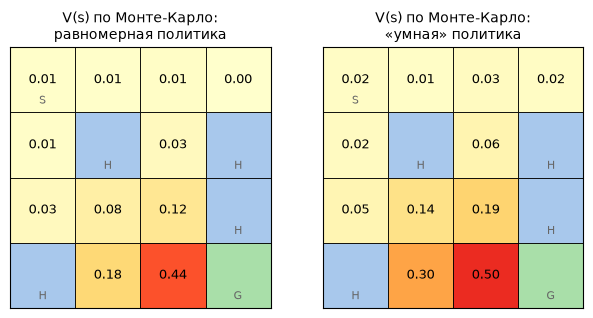

In [4]:
uniform = np.ones((n_states, n_actions)) / n_actions                    # кубик в каждой клетке
smart = 0.7 * shortest_path_policy(desc) + 0.3 * uniform                # чаще идёт по кратчайшему пути, иногда наугад

rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
for ax, (name, policy) in zip(axes, [("равномерная политика", uniform), ("«умная» политика", smart)]):
    sessions = [run_session(lake, policy, rng) for _ in range(3000)]
    plot_values(estimate_values(sessions, n_states), desc, ax=ax, vmax=0.6, title=f"V(s) по Монте-Карло:\n{name}")
plt.show()

Одна среда, одна цель, одинаковая награда — а числа в клетках разные, потому что ценность измеряет не клетку, а **клетку вместе с тем, что агент будет делать дальше**. У терминальных клеток ценность равна нулю по определению: будущего у них нет, а награда за вход в цель уже учтена в ценности соседней клетки.

<details>
<summary><b>Самопроверка.</b> Когда $V^\pi(s) = Q^\pi(s, a)$?</summary>

Когда политика в $s$ детерминированная и выбирает именно $a$: тогда среднее по действиям состоит из одного слагаемого. В общем случае $V^\pi(s)$ — выпуклая комбинация чисел $Q^\pi(s, \cdot)$, поэтому $\min_a Q^\pi(s, a) \le V^\pi(s) \le \max_a Q^\pi(s, a)$. Это неравенство — зерно идеи «улучшить политику» из раздела 6.

</details>

Пока эти числа получены дорого: 3000 сыгранных эпизодов и всё равно с шумом. Сейчас увидим, что их можно **вычислить точно**.

## 5. Уравнения Беллмана

### 5.1 Вывод

Возьмём тождество $G_t = R_t + \gamma G_{t+1}$ и подставим его в определение ценности:

$$
V^\pi(s) = \mathbb E_\pi[\,R_t + \gamma G_{t+1} \mid S_t = s\,]
        = \mathbb E_\pi[\,R_t \mid S_t = s\,] + \gamma\, \mathbb E_\pi[\,G_{t+1} \mid S_t = s\,].
$$

Первое слагаемое — $r_\pi(s)$. Во втором усредним сначала по действию $a \sim \pi(\cdot \mid s)$, затем по исходу $s' \sim P(\cdot \mid s, a)$, а дальше по марковскому свойству будущее зависит только от $s'$, и $\mathbb E_\pi[G_{t+1} \mid S_{t+1} = s'] = V^\pi(s')$. Получаем **уравнение Беллмана для $V^\pi$**:

$$
\boxed{\,V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s, a)\,\big[\, R(s, a, s') + \gamma\, V^\pi(s') \,\big]\,}
$$

и точно так же **для $Q^\pi$**:

$$
\boxed{\,Q^\pi(s, a) = \sum_{s'} P(s' \mid s, a)\,\Big[\, R(s, a, s') + \gamma \sum_{a'} \pi(a' \mid s')\, Q^\pi(s', a') \,\Big]\,}
$$

Словами: **ценность состояния — это награда за один шаг плюс дисконтированная ценность того, где окажемся, усреднённая по всему, что может случиться за этот шаг.** Схема, по которой это принято рисовать, называется backup-диаграммой:

![backup](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/bellman_backup.png)

<details>
<summary><b>Самопроверка.</b> Выпишите уравнение Беллмана для клетки 14 скользкого озера при равномерной политике. Какие клетки в нём участвуют?</summary>

Из клетки 14 четыре действия, каждое с вероятностью $1/4$; каждое действие с вероятностью $1/3$ ведёт в одну из трёх соседних клеток (в стену — остаёмся в 14). Участвуют клетки 10, 13, 15 и сама 14; переход в 15 даёт награду 1 и дальше ценность 0. В итоге $V(14) = \tfrac{1}{4}\sum_a \tfrac{1}{3}\sum_{s'}[R + 0.95\,V(s')]$, где ненулевая награда только у переходов в 15.

</details>

### 5.2 Это линейная система

Уравнение выглядит громоздко, но при фиксированной политике оно **линейно** по неизвестным $V^\pi(s)$. В обозначениях раздела 3 — в матричной форме:

$$
V^\pi = r_\pi + \gamma P_\pi V^\pi
\quad\Longrightarrow\quad
(I - \gamma P_\pi)\, V^\pi = r_\pi
\quad\Longrightarrow\quad
V^\pi = (I - \gamma P_\pi)^{-1} r_\pi .
$$

Матрица $I - \gamma P_\pi$ обратима при $\gamma < 1$ (у $P_\pi$ все собственные числа по модулю $\le 1$, поэтому у $\gamma P_\pi$ они строго меньше 1). Значит, ценность любой политики в конечном MDP — это **решение системы из $|\mathcal S|$ линейных уравнений**. Никаких эпизодов, никакого шума. Сравним с Монте-Карло.

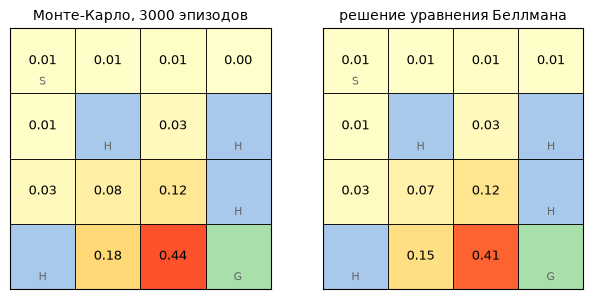

наибольшее расхождение по посещённым клеткам: 0.027


In [5]:
def policy_evaluation_exact(P, R, policy, gamma=GAMMA):
    """V^π = (I - γ P_π)^{-1} r_π — точное решение уравнения Беллмана для заданной политики."""
    P_pi = np.einsum("sa,sat->st", policy, P)                # P_π[s, s'] = Σ_a π(a|s) P(s'|s, a)
    r_pi = (policy * R).sum(axis=1)                          # r_π[s]    = Σ_a π(a|s) r(s, a)
    return np.linalg.solve(np.eye(len(r_pi)) - gamma * P_pi, r_pi)

V_exact = policy_evaluation_exact(P, R, uniform)
rng = np.random.default_rng(1)
V_mc = estimate_values([run_session(lake, uniform, rng) for _ in range(3000)], n_states)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
plot_values(V_mc, desc, ax=axes[0], vmax=0.6, title="Монте-Карло, 3000 эпизодов")
plot_values(V_exact, desc, ax=axes[1], vmax=0.6, title="решение уравнения Беллмана")
plt.show()
print(f"наибольшее расхождение по посещённым клеткам: {np.nanmax(np.abs(V_mc - V_exact)):.3f}")

Одна строка `np.linalg.solve` дала то, на что Монте-Карло потратил 3000 эпизодов, — и дала **точно**: правая карта не шумит, и её можно посчитать для любой политики, даже для той, которая никогда не доходит до цели.

<details>
<summary><b>Самопроверка (со звёздочкой).</b> Посчитайте $V^{\text{uniform}}$ для нескользкого озера. Почему ответ совпадёт с картой выше?</summary>

При равномерной политике $P_\pi(s' \mid s) = \tfrac14 \sum_a P(s' \mid s, a)$. На скользком льду действие $a$ ведёт с вероятностью $1/3$ в каждое из трёх направлений $a-1, a, a+1$; суммируя по всем четырём $a$, каждое направление получает вес $\tfrac14 \cdot 3 \cdot \tfrac13 = \tfrac14$ — ровно как без скольжения. Цепи $P_\pi$ совпадают, значит, совпадают и ценности. Разница между озёрами видна только тем политикам, которые *выбирают*.

</details>

### 5.3 Уравнение как неподвижная точка

Есть и второй способ решить систему, и он важнее первого, потому что переживёт переход к большим задачам. Запишем правую часть уравнения как оператор $T^\pi V = r_\pi + \gamma P_\pi V$. Тогда $V^\pi$ — его **неподвижная точка**: $T^\pi V^\pi = V^\pi$. Возьмём произвольный вектор и будем применять оператор снова и снова.

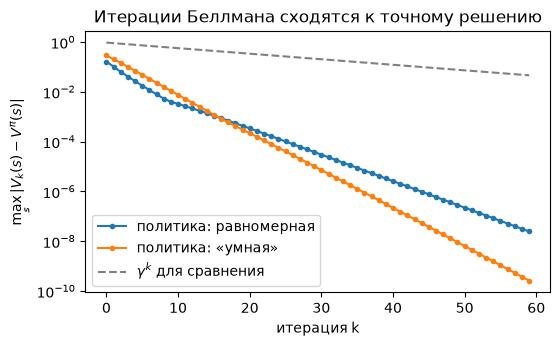

In [6]:
def bellman_iterations(P, R, policy, n_iter=60, gamma=GAMMA):
    """V ← r_π + γ P_π V, начиная с нуля. Возвращает список ошибок относительно точного решения."""
    P_pi, r_pi = np.einsum("sa,sat->st", policy, P), (policy * R).sum(axis=1)
    V_star, V, errors = policy_evaluation_exact(P, R, policy, gamma), np.zeros(len(r_pi)), []
    for _ in range(n_iter):
        V = r_pi + gamma * P_pi @ V
        errors.append(np.abs(V - V_star).max())
    return errors

plt.figure(figsize=(6, 3.4))
for name, policy in [("равномерная", uniform), ("«умная»", smart)]:
    plt.semilogy(bellman_iterations(P, R, policy), marker=".", label=f"политика: {name}")
plt.semilogy(GAMMA ** np.arange(1, 61), "--", color="grey", label=r"$\gamma^k$ для сравнения")
plt.xlabel("итерация k"); plt.ylabel(r"$\max_s |V_k(s) - V^\pi(s)|$"); plt.legend(); plt.title("Итерации Беллмана сходятся к точному решению")
plt.show()

Ошибка убывает **геометрически**, не медленнее чем $\gamma^k$: каждое применение оператора сжимает расстояние до ответа как минимум в $1/\gamma$ раз. Это свойство называется **сжимающим отображением**, и на неделе 3 мы докажем его в одну строку — оно и есть причина, по которой работают динамическое программирование и TD-обучение. Заметьте, что итерации не требуют обращать матрицу: только умножать и складывать. Для миллиона состояний это единственный вариант.

Промежуточный итог: **ценность политики — не статистика, а решение уравнения.** Уравнение можно решить точно (линейная система) или итерациями (неподвижная точка). Осталось научиться не оценивать заданную политику, а находить лучшую.

## 6. Оптимальная политика и уравнения оптимальности

### 6.1 Что значит «лучше»

Сравним политики покомпонентно: $\pi \ge \pi'$, если $V^\pi(s) \ge V^{\pi'}(s)$ **для всех** состояний $s$. Это частичный порядок: две политики могут быть несравнимы (одна лучше слева от озера, другая справа). Тем удивительнее теорема, с которой начинается вся теория MDP.

> **Теорема** (Bellman 1957, Puterman 1994). В конечном MDP с $\gamma < 1$ существует политика $\pi^*$, которая не хуже любой другой во всех состояниях сразу. Среди таких политик есть **детерминированная** и **стационарная** (не зависящая от времени). Все оптимальные политики имеют одну и ту же функцию ценности $V^*$ и одну и ту же $Q^*$:
>
> $$
> V^*(s) = \max_\pi V^\pi(s), \qquad Q^*(s, a) = \max_\pi Q^\pi(s, a).
> $$

Доказательство мы опустим (оно есть в Puterman, гл. 6), но заметим, что теорема содержательна: она обещает, что случайность в политике нужна только на время обучения, а итоговое решение всегда можно записать таблицей «состояние → действие».

### 6.2 Уравнения оптимальности

Для оптимальной политики уравнение Беллмана приобретает особую форму. Оптимальный агент в каждом состоянии выбирает **лучшее** действие, а лучшее действие — то, у которого $Q^*$ больше:

$$
V^*(s) = \max_a Q^*(s, a).
$$

Подставляя это в связь $Q$ через $V$ из раздела 4, получаем **уравнения оптимальности Беллмана**:

$$
\boxed{\,V^*(s) = \max_a \sum_{s'} P(s' \mid s, a)\,\big[\, R(s, a, s') + \gamma\, V^*(s') \,\big]\,}
\qquad
\boxed{\,Q^*(s, a) = \sum_{s'} P(s' \mid s, a)\,\big[\, R(s, a, s') + \gamma \max_{a'} Q^*(s', a') \,\big]\,}
$$

Разница с уравнениями раздела 5 ровно одна: усреднение по политике $\sum_a \pi(a \mid s)$ заменилось на $\max_a$. Мы больше не знаем политику — мы её ищем, и уравнение говорит, что оптимальная политика **жадная по отношению к $Q^*$**:

$$
\pi^*(s) = \arg\max_a Q^*(s, a).
$$

Отсюда центральная идея value-based методов: **если знаешь $Q^*$, оптимальная политика достаётся бесплатно** — в каждом состоянии выбирай действие с наибольшей ценностью. Не нужно ни перебирать $4^{16}$ политик, ни играть эпизоды.

### 6.3 Цена вопроса

Максимум — **нелинейная** операция. Уравнение оптимальности уже нельзя решить одной строкой `np.linalg.solve`; зато второй способ из раздела 5 — итерации неподвижной точки — работает по-прежнему, потому что оператор с $\max$ тоже сжимающий. Заглянем на неделю 3 и решим уравнение оптимальности прямо сейчас: это шесть строк.

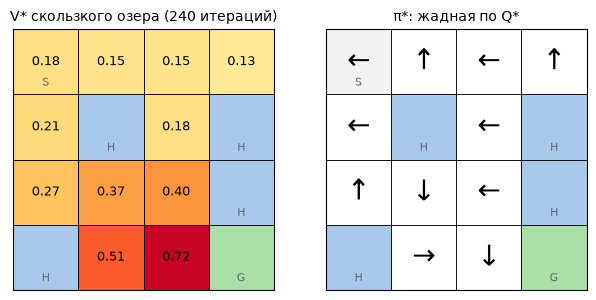

V*(старт) = 0.180;  по 2000 эпизодам: средний return 0.181, доля успехов 72.8%


In [7]:
def value_iteration(P, R, gamma=GAMMA, tol=1e-10):
    """Итерации V ← max_a [ r(s,a) + γ Σ_s' P(s'|s,a) V(s') ] до сходимости. Возвращает V*, Q* и число итераций."""
    V = np.zeros(P.shape[0])
    for k in range(10_000):
        Q = R + gamma * P @ V                                   # Q[s, a] = r(s, a) + γ Σ_s' P(s'|s, a) V(s')
        V_new = Q.max(axis=1)
        if np.abs(V_new - V).max() < tol:
            return V_new, Q, k
        V = V_new

V_star, Q_star, n_iter = value_iteration(P, R)
pi_star = np.eye(n_actions)[Q_star.argmax(axis=1)]            # жадная политика: в каждой клетке argmax_a Q*(s, a)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
plot_values(V_star, desc, ax=axes[0], title=f"V* скользкого озера ({n_iter} итераций)")
draw_policy(pi_star, desc, ax=axes[1], title="π*: жадная по Q*")
plt.show()

rng = np.random.default_rng(0)
sessions = [run_session(lake, pi_star, rng) for _ in range(2000)]
print(f"V*(старт) = {V_star[0]:.3f};  по 2000 эпизодам: средний return {np.mean([discounted_return(r) for *_, r in sessions]):.3f}, "
      f"доля успехов {np.mean([sum(r) > 0 for *_, r in sessions]):.1%}")

Посмотрите на стрелки. В стартовой клетке оптимально идти **влево, в стену**, в клетке под ней — тоже: шаг в стену оставляет на месте, а сносит только вбок, и так агент дрейфует вниз вдоль безопасного края, никогда не рискуя провалиться. В лекции 1 мы заметили этот трюк глазами, разглядывая таблицу переходов одной клетки; уравнение оптимальности нашло его для всех клеток сразу, за долю секунды, и гарантирует, что лучше нельзя. Средний return по 2000 эпизодам совпал с $V^*(\text{старт})$ — теория и эксперимент сошлись.

Это и есть ответ на вопрос «чему мы научились»: на прошлой неделе хорошую политику приходилось **искать** — играть тысячи эпизодов и отбирать удачные; сегодня её можно **вычислить** из уравнения. Цена — знание $P$ и $R$. Как обойтись без них, не теряя уравнения, — тема всего остального курса.

> **Факт.** AlphaZero использует ту же пару объектов: одна нейросеть выдаёт для позиции и политику $\pi(a \mid s)$, и ценность $V(s)$; поиск по дереву — это, по сути, несколько шагов уравнения Беллмана, выполненных на лету перед каждым ходом.

## 7. Одно уравнение — весь курс

Всё, что будет дальше, — способы решать уравнения Беллмана, когда что-то из «роскоши» этой лекции недоступно: нет $P$ и $R$, состояний слишком много для таблицы, или и то и другое.

![family](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/bellman_family.png)

| Метод | Что известно | Как решает уравнение | Неделя |
|---|---|---|---|
| **Динамическое программирование** (policy iteration, value iteration) | $P$, $R$, таблица | итерации неподвижной точки, как в разделах 5–6 | 3 |
| **Monte-Carlo** | только возможность играть | заменяет $\mathbb E[G_t]$ средним по эпизодам; уравнение не использует | 3 |
| **TD-обучение, SARSA, Q-learning** | только возможность играть | заменяет матожидание в уравнении **одним переходом**: сдвигает $V(s)$ к $r + \gamma V(s')$ | 3 |
| **DQN** | играть; состояний много | $Q$ — нейросеть, невязка уравнения оптимальности — функция потерь | 6 |
| **Actor-Critic, PPO** | играть; действий много или они непрерывные | критик учит $V^\pi$ по уравнению Беллмана, актор улучшает $\pi$ по его оценкам | 8–9 |
| **Model-based RL** | играть | сначала выучить $P$ и $R$ по данным, потом как в DP | 11–12 |

Общий приём, который стоит увидеть уже сейчас: величина

$$
\delta = r + \gamma V(s') - V(s)
$$

называется **невязкой Беллмана** (TD-error). Для истинного $V^\pi$ она в среднем равна нулю — это и есть уравнение. Если $V$ — таблица или нейросеть с параметрами, невязка говорит, в какую сторону их сдвинуть. Половина алгоритмов курса устроена как «посчитай $\delta$ и сделай шаг».

⏱ **Если есть время: $\gamma$ меняет не только числа, но и политику.** Дисконт — часть постановки задачи, а не гиперпараметр алгоритма. Решим уравнение оптимальности при трёх значениях $\gamma$.

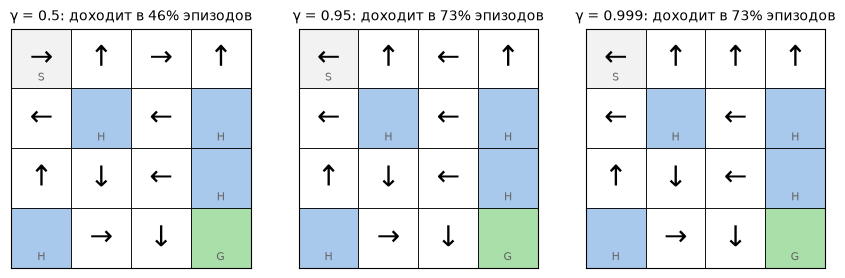

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4))
rng = np.random.default_rng(0)
for ax, gamma in zip(axes, [0.5, 0.95, 0.999]):
    V_g, Q_g, _ = value_iteration(P, R, gamma=gamma)
    pi_g = np.eye(n_actions)[Q_g.argmax(axis=1)]
    success = np.mean([sum(r) > 0 for *_, r in [run_session(lake, pi_g, rng, max_steps=500) for _ in range(1000)]])
    draw_policy(pi_g, desc, ax=ax, title=f"γ = {gamma}: доходит в {success:.0%} эпизодов")
plt.show()

При $\gamma = 0.5$ агент «нетерпелив»: награда через десять шагов весит $2^{-10}$, и из стартовой клетки он готов рискнуть ради скорости — и тонет вдвое чаще. При $\gamma = 0.95$ и выше выигрывает осторожность: агенту не жалко лишних шагов, и он идёт вдоль безопасного края. Обе политики оптимальны — каждая для своей задачи. Выбирая $\gamma$, вы выбираете, **какую задачу** решает агент.

## 8. Итоги

1. **MDP — это $\langle \mathcal S, \mathcal A, P, R, \gamma \rangle$.** Два массива, $P[s, a, s']$ и $R[s, a]$, описывают среду целиком; марковское свойство — требование к тому, что мы называем состоянием.
2. **Фиксированная политика превращает MDP в цепь** с матрицей $P_\pi$ и наградами $r_\pi$; return рекурсивен: $G_t = R_t + \gamma G_{t+1}$.
3. **Ценность — центральный объект курса.** $V^\pi(s)$ и $Q^\pi(s, a)$ — ожидаемый return из состояния или из пары; они связаны друг с другом и с соседями **уравнениями Беллмана**. Для заданной политики это линейная система: решается точно или итерациями, которые сходятся геометрически.
4. **Оптимальная политика существует, детерминирована и жадна по $Q^*$.** Уравнения оптимальности отличаются от обычных заменой $\sum_a \pi$ на $\max_a$; их решают итерациями, и они дают то, что перебор и Cross-Entropy искали вслепую.
5. **Все методы курса — способы решать эти уравнения** без таблицы $P$, без таблицы $V$ или без того и другого; невязка Беллмана $r + \gamma V(s') - V(s)$ — их общий строительный блок.

Словарь, который нужно унести с собой: **MDP, ядро переходов $P$, ожидаемая награда $r(s, a)$, терминальное состояние как поглощающее, $P_\pi$ и $r_\pi$, return $G_t$, тождество $G_t = R_t + \gamma G_{t+1}$, ценность состояния $V^\pi$, ценность действия $Q^\pi$, уравнение Беллмана, backup-диаграмма, неподвижная точка и сжимающее отображение, оптимальная политика, $V^*$, $Q^*$, уравнение оптимальности, жадная политика, невязка Беллмана**.

## Литература

* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction*, 2nd ed. — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). **Глава 3** — ровно эта лекция: MDP, return, ценность, уравнения Беллмана, оптимальность. Разделы 3.5–3.6 стоит прочитать до семинара.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), **лекция 2 «Markov Decision Processes»** — тот же материал с другими примерами (student MDP).
* M. Puterman. *Markov Decision Processes: Discrete Stochastic Dynamic Programming* (1994), гл. 6 — строгие доказательства существования оптимальной политики и сходимости итераций.
* [OpenAI Spinning Up: Key Concepts in RL](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html) — краткая сводка обозначений, включая непрерывный случай.

## На семинаре и дома

* **Семинар** (`../seminar/seminar.ipynb`) идёт по лекции: пишем свою среду GridWorld, достаём из неё матрицы $P$ и $R$, оцениваем политику тремя способами (Монте-Карло, линейная система, итерации Беллмана) и убеждаемся, что ответы совпадают; считаем $Q^\pi$, делаем шаг жадного улучшения и решаем уравнение оптимальности на скользком поле.
* **ДЗ** (`../homework/homework.ipynb`): среда «управление запасами» как `gym.Env`, её точная модель $P$, $R$ из распределения спроса, ценность ручной политики точно и по Монте-Карло, оптимальная политика заказов через уравнение оптимальности; теория — вывод уравнений Беллмана и MDP на бумаге.
* **Неделя 3**: как решать уравнения Беллмана **без** $P$ и $R$ — по сыгранным переходам: Monte-Carlo, TD-обучение, SARSA и Q-learning; и почему всё это сходится (сжимающие отображения).